In [4]:
# ── Import all tools we need ──────────────────────────────────────────────
import pandas as pd                     # data tables
import numpy as np                      # numbers & arrays
import matplotlib.pyplot as plt         # basic charts
import seaborn as sns                   # pretty charts
import warnings
warnings.filterwarnings('ignore')       # hide unimportant warnings

# Machine-learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
confusion_matrix, roc_auc_score, roc_curve)

# Chart style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='darkgrid', palette='muted')

print("All libraries imported successfully!")


All libraries imported successfully!


In [5]:
# ── Load the dataset ──────────────────────────────────────────────────────
df = pd.read_csv('/Users/OM/Downloads/spam_email_dataset.csv')

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Label counts  : Spam={df['label'].sum():,}  |  Ham={len(df)-df['label'].sum():,}")
print()
df.head(5)


Dataset shape : 10,000 rows × 20 columns
Label counts  : Spam=3,995  |  Ham=6,005



,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [6]:
# ── Column names & types ──────────────────────────────────────────────────
print("Column names & data types:")
print(df.dtypes)
print()

# ── Check for missing values ──────────────────────────────────────────────
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
if missing.sum() == 0:
    print("Great! No missing values found.")
print()

# ── Basic statistics ───────────────────────────────────────────────────────
print("Basic Statistics (numeric columns):")
df.describe().T.style.background_gradient(cmap='Blues')


Column names & data types:
email_id                     int64
subject                        str
email_text                     str
num_words                    int64
num_characters               int64
num_exclamation_marks        int64
num_links                    int64
has_suspicious_link          int64
num_attachments              int64
has_attachment               int64
sender_email                   str
sender_domain                  str
sender_reputation_score    float64
email_hour                   int64
email_day_of_week            int64
is_weekend                   int64
num_recipients               int64
contains_money_terms         int64
contains_urgency_terms       int64
label                        int64
dtype: object

Total missing values: 0
Great! No missing values found.

Basic Statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
email_id,10000.000000,4999.500000,2886.895680,0.000000,2499.750000,4999.500000,7499.250000,9999.000000
num_words,10000.000000,18.097000,5.163764,5.000000,14.000000,18.000000,22.000000,33.000000
num_characters,10000.000000,115.072400,33.781247,25.000000,91.000000,115.500000,139.000000,221.000000
num_exclamation_marks,10000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
num_links,10000.000000,3.976400,2.580447,0.000000,2.000000,4.000000,6.000000,8.000000
has_suspicious_link,10000.000000,0.466700,0.498915,0.000000,0.000000,0.000000,1.000000,1.000000
num_attachments,10000.000000,0.803600,0.752252,0.000000,0.000000,1.000000,1.000000,2.000000
has_attachment,10000.000000,0.599600,0.490004,0.000000,0.000000,1.000000,1.000000,1.000000
sender_reputation_score,10000.000000,0.681972,0.172825,0.300000,0.560000,0.690000,0.810000,1.000000
email_hour,10000.000000,11.589600,6.897023,0.000000,6.000000,12.000000,18.000000,23.000000


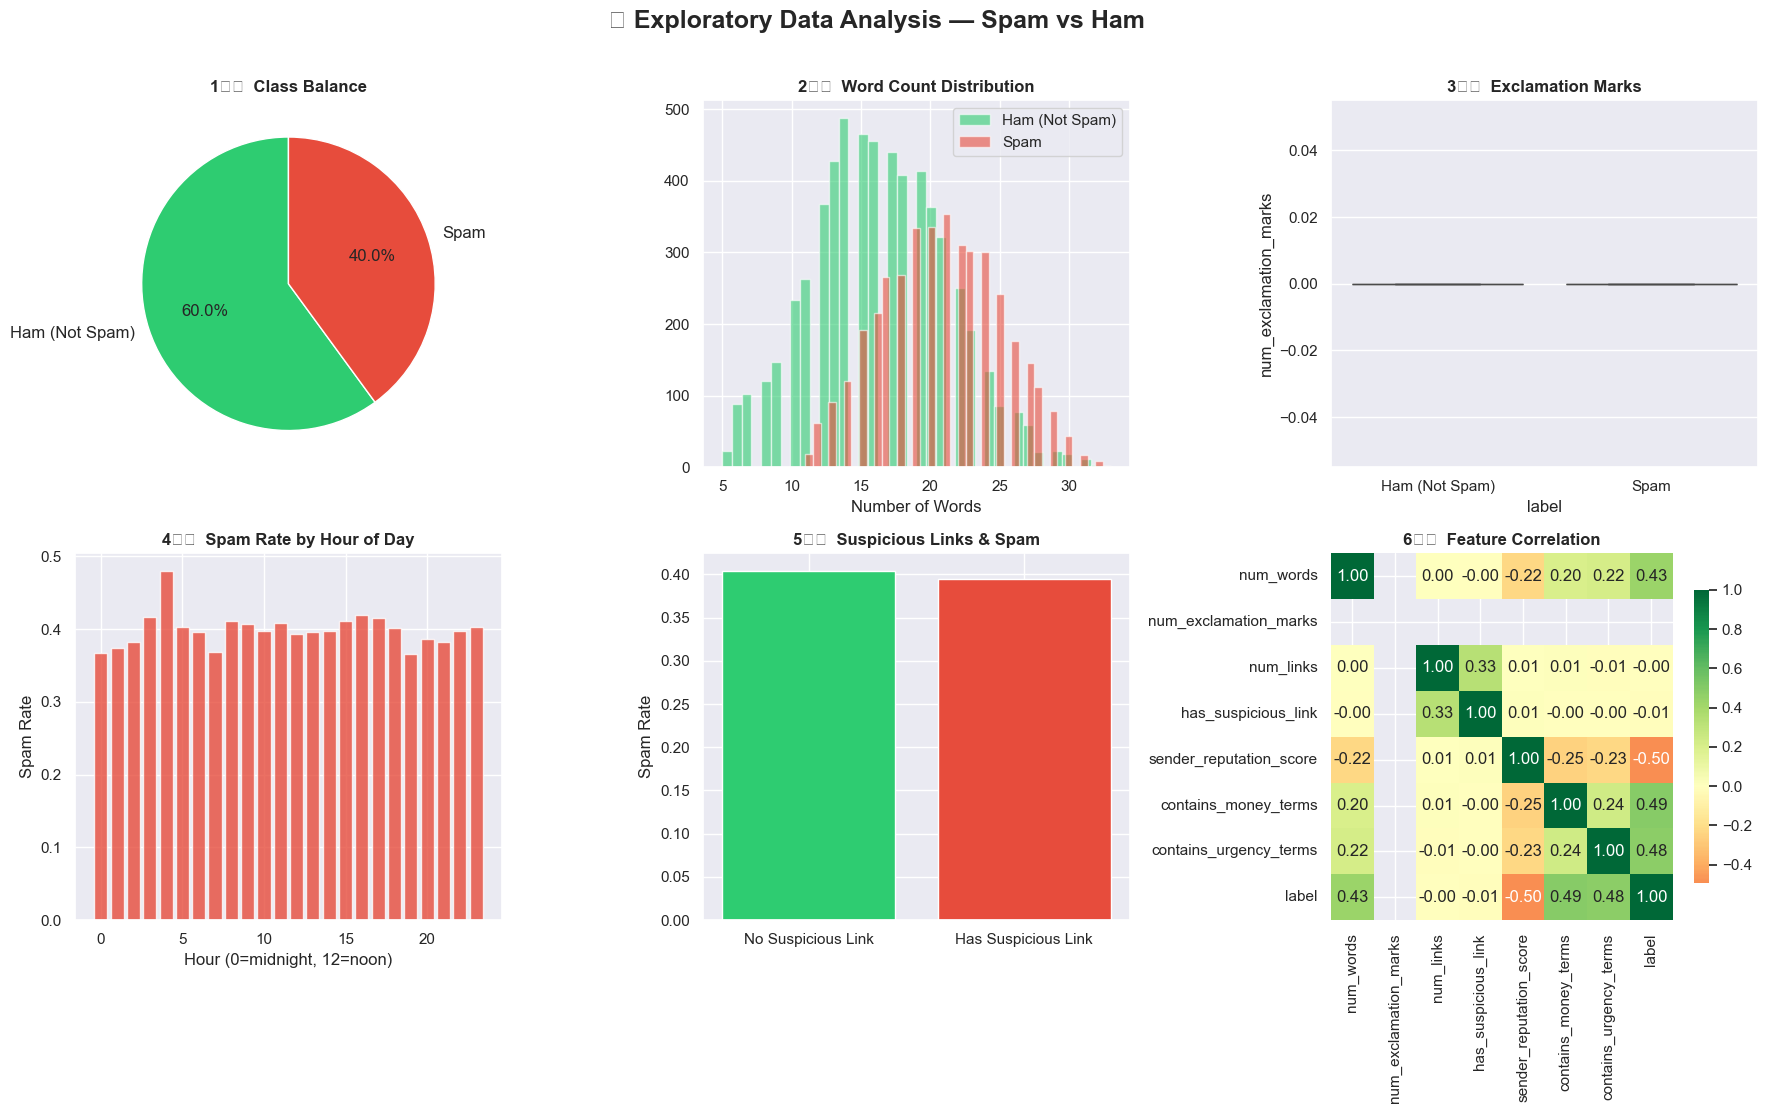

Charts plotted! Study each one before moving forward.


In [7]:
# VISUALISING THE DATA

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('📊 Exploratory Data Analysis — Spam vs Ham',
             fontsize=18, fontweight='bold', y=1.01)

colors = ['#2ecc71', '#e74c3c']   # green=ham, red=spam
labels = ['Ham (Not Spam)', 'Spam']

# ── 1. Class balance pie chart ─────────────────────────────────────────────
counts = df['label'].value_counts()
axes[0, 0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('1️⃣  Class Balance', fontweight='bold')

# ── 2. Word count distribution ─────────────────────────────────────────────
for lbl, col in zip([0, 1], colors):
    axes[0, 1].hist(df[df['label'] == lbl]['num_words'],
                    bins=40, alpha=0.6, color=col, label=labels[lbl])
axes[0, 1].set_title('2️⃣  Word Count Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Number of Words')
axes[0, 1].legend()

# ── 3. Exclamation marks ──────────────────────────────────────────────────
sns.boxplot(data=df, x='label', y='num_exclamation_marks',
            palette=colors, ax=axes[0, 2])
axes[0, 2].set_title('3️⃣  Exclamation Marks', fontweight='bold')
axes[0, 2].set_xticklabels(labels)

# ── 4. Email hour heatmap ─────────────────────────────────────────────────
hour_spam = df.groupby('email_hour')['label'].mean().reset_index()
axes[1, 0].bar(hour_spam['email_hour'], hour_spam['label'],
               color='#e74c3c', alpha=0.8)
axes[1, 0].set_title('4️⃣  Spam Rate by Hour of Day', fontweight='bold')
axes[1, 0].set_xlabel('Hour (0=midnight, 12=noon)')
axes[1, 0].set_ylabel('Spam Rate')

# ── 5. Suspicious links ───────────────────────────────────────────────────
link_spam = df.groupby('has_suspicious_link')['label'].mean()
axes[1, 1].bar(['No Suspicious Link', 'Has Suspicious Link'],
               link_spam.values, color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('5️⃣  Suspicious Links & Spam', fontweight='bold')
axes[1, 1].set_ylabel('Spam Rate')

# ── 6. Correlation heatmap ────────────────────────────────────────────────
num_cols = ['num_words', 'num_exclamation_marks', 'num_links',
            'has_suspicious_link', 'sender_reputation_score',
            'contains_money_terms', 'contains_urgency_terms', 'label']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1, 2], cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('6️⃣  Feature Correlation', fontweight='bold')

plt.tight_layout()
plt.show()
print("Charts plotted! Study each one before moving forward.")


In [8]:
# ── Select numeric feature columns ────────────────────────────────────────
FEATURES = [
    'num_words', 'num_characters', 'num_exclamation_marks', 'num_links',
    'has_suspicious_link', 'num_attachments', 'has_attachment',
    'sender_reputation_score', 'email_hour', 'email_day_of_week',
    'is_weekend', 'num_recipients', 'contains_money_terms',
    'contains_urgency_terms'
]

X = df[FEATURES]   # features (inputs)
y = df['label']    # target  (what we want to predict)

print(f"Features selected : {X.shape[1]} columns")
print(f"Total samples     : {X.shape[0]:,}")
print()

# ── Train / Test split (80% train, 20% test) ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print()

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # learn scale from train only
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print("Features scaled! Ready to train models.")


Features selected : 14 columns
Total samples     : 10,000

Training samples : 8,000
Testing samples  : 2,000

Features scaled! Ready to train models.


In [10]:
train_df = pd.concat([X_train, pd.DataFrame(y_train, columns=["target"])], axis=1)
test_df = pd.concat([X_test, pd.DataFrame(y_test, columns=["target"])], axis=1)

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Train/Test saved without scaling")

Train/Test saved without scaling


In [11]:
# ── Define models ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                  : SVC(probability=True, random_state=42),
    'KNN'                  : KNeighborsClassifier(n_neighbors=5),
}

results = []

print("Training models — please wait...")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'CV Score':>10}")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train_sc, y_train)                  # train
    y_pred  = model.predict(X_test_sc)              # predict labels
    y_prob  = model.predict_proba(X_test_sc)[:, 1]  # predict probabilities
    
    acc     = accuracy_score(y_test, y_pred)
    roc     = roc_auc_score(y_test, y_prob)
    cv      = cross_val_score(model, X_train_sc, y_train,
                              cv=5, scoring='accuracy').mean()
    
    results.append({'Model': name, 'Accuracy': acc,
                    'ROC-AUC': roc, 'CV Score': cv})
    print(f"{name:<25} {acc:>9.4f} {roc:>10.4f} {cv:>10.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print()
print("All models trained!")


Training models — please wait...
Model                       Accuracy    ROC-AUC   CV Score
------------------------------------------------------------
Logistic Regression          0.8740     0.9524     0.8898
Random Forest                0.8880     0.9604     0.9001
Gradient Boosting            0.8935     0.9672     0.9065
SVM                          0.8755     0.9492     0.8914
KNN                          0.8455     0.9145     0.8592

All models trained!


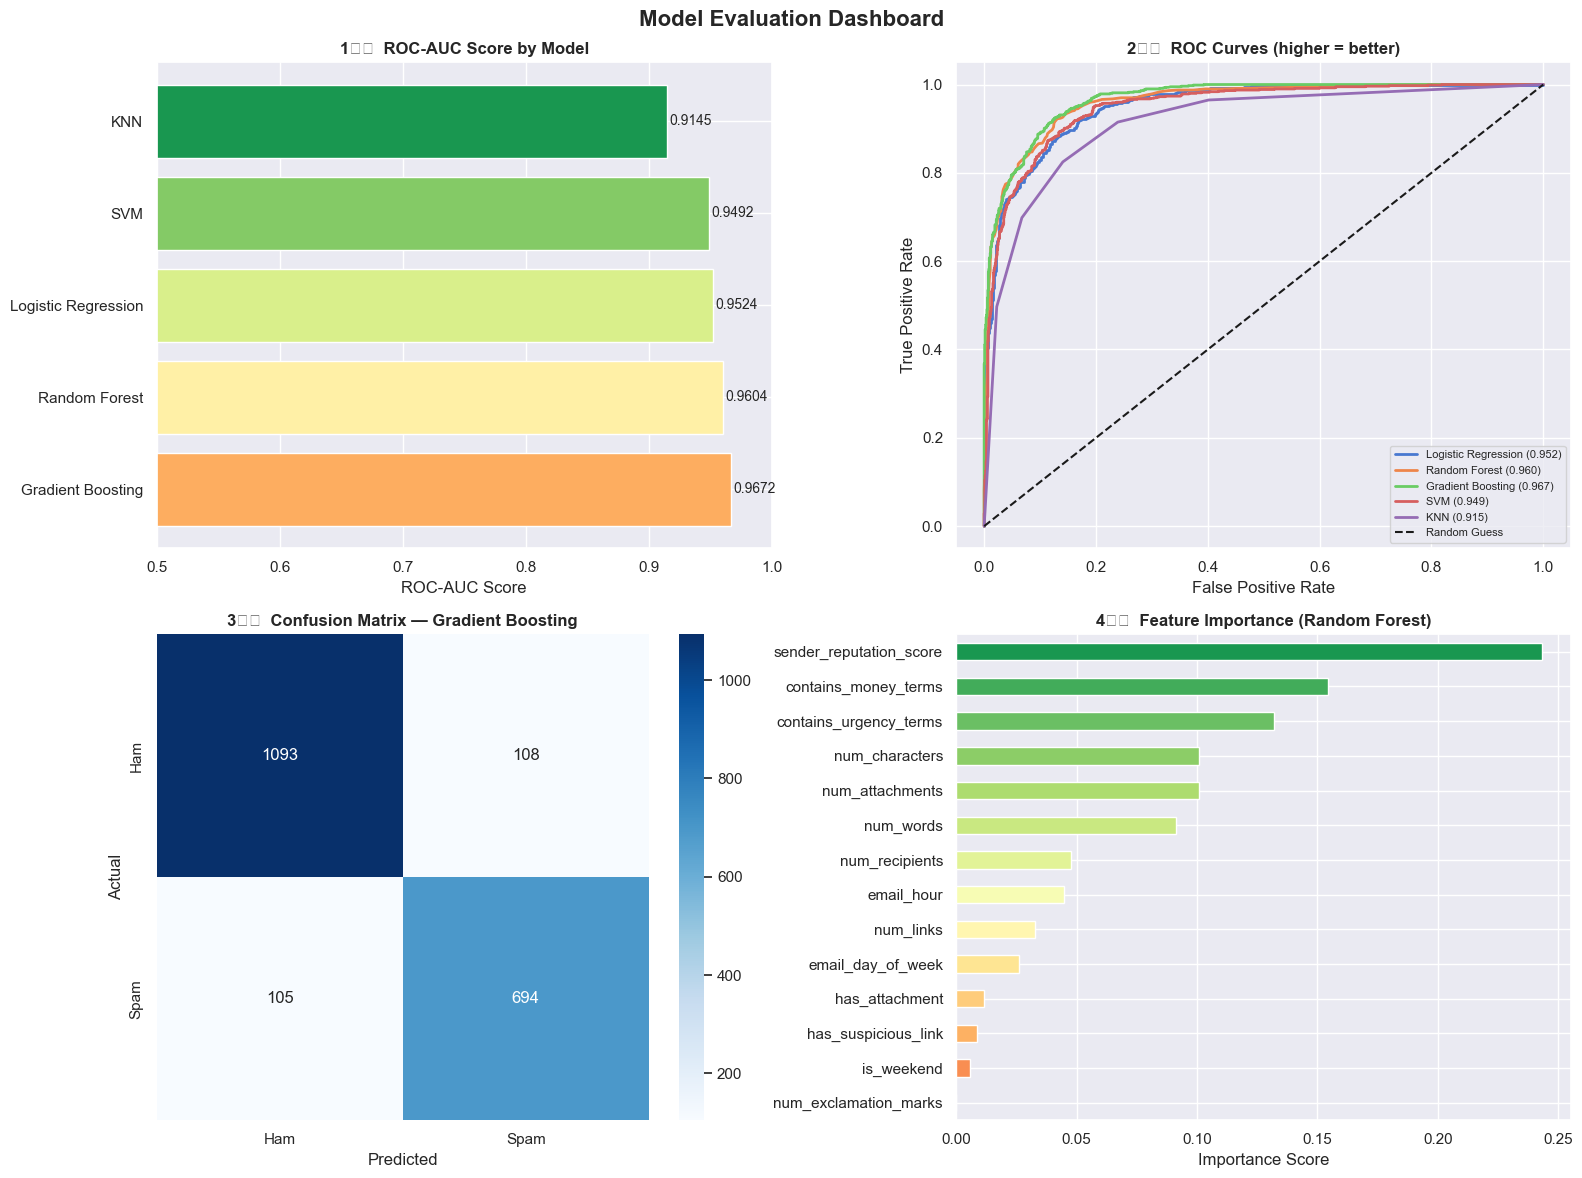

 Best Model: Gradient Boosting
              precision    recall  f1-score   support

         Ham       0.91      0.91      0.91      1201
        Spam       0.87      0.87      0.87       799

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Evaluation Dashboard',
             fontsize=16, fontweight='bold')

# ── 1. Model comparison bar chart ─────────────────────────────────────────
bars = axes[0, 0].barh(results_df['Model'], results_df['ROC-AUC'],
                        color=plt.cm.RdYlGn(
                            np.linspace(0.3, 0.9, len(results_df))))
axes[0, 0].set_xlim(0.5, 1.0)
axes[0, 0].set_title('1️⃣  ROC-AUC Score by Model', fontweight='bold')
axes[0, 0].set_xlabel('ROC-AUC Score')
for bar, val in zip(bars, results_df['ROC-AUC']):
    axes[0, 0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
 f'{val:.4f}', va='center', fontsize=10)

# ── 2. ROC curves for all models ──────────────────────────────────────────
for name, model in models.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0, 1].plot(fpr, tpr, label=f'{name} ({auc:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0, 1].set_title('2️⃣  ROC Curves (higher = better)', fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(fontsize=8)

# ── 3. Best model — confusion matrix ──────────────────────────────────────
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
  xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1, 0].set_title(f'3️⃣  Confusion Matrix — {best_name}', fontweight='bold')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicted')

# ── 4. Feature importance (Random Forest) ─────────────────────────────────
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[1, 1],
 color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp))))
axes[1, 1].set_title('4️⃣  Feature Importance (Random Forest)', fontweight='bold')
axes[1, 1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# ── Best model classification report ──────────────────────────────────────
print(f" Best Model: {best_name}")
print("=" * 50)
print(classification_report(y_test, y_pred_best,
target_names=['Ham', 'Spam']))
